In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('✅ Import thành công!')

✅ Import thành công!


In [4]:
df = pd.read_csv('clean_no_outlier.csv')

counts = df['Loan_Status'].value_counts()
total  = len(df)

print('=' * 50)
print('       THÔNG TIN DỮ LIỆU ĐẦU VÀO')
print('=' * 50)
print(f'Nguồn      : clean_no_outlier.csv (từ Phần 2)')
print(f'Kích thước : {df.shape[0]} hồ sơ × {df.shape[1]} cột')
print(f'Cột        : {df.columns.tolist()}')
print(f'Missing    : {df.isnull().sum().sum()} ô ← Phần 2 đã xử lý')
print()
print('Phân phối nhãn Loan_Status:')
print(f'  Được duyệt (1) : {counts[1]:>4} hồ sơ = {counts[1]/total*100:.1f}%')
print(f'  Từ chối   (0)  : {counts[0]:>4} hồ sơ = {counts[0]/total*100:.1f}%')
print(f'  Mất cân bằng   : {counts[1]/counts[0]:.2f} lần')
print()
print('⚠️  Dữ liệu chưa scale — Pipeline sẽ scale trong lúc train')
print('⚠️  Mất cân bằng 69/31 → dùng F1 làm chỉ số đánh giá chính')

df.head()

       THÔNG TIN DỮ LIỆU ĐẦU VÀO
Nguồn      : clean_no_outlier.csv (từ Phần 2)
Kích thước : 571 hồ sơ × 7 cột
Cột        : ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']
Missing    : 0 ô ← Phần 2 đã xử lý

Phân phối nhãn Loan_Status:
  Được duyệt (1) :  394 hồ sơ = 69.0%
  Từ chối   (0)  :  177 hồ sơ = 31.0%
  Mất cân bằng   : 2.23 lần

⚠️  Dữ liệu chưa scale — Pipeline sẽ scale trong lúc train
⚠️  Mất cân bằng 69/31 → dùng F1 làm chỉ số đánh giá chính


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,5849,0.0,128.0,360.0,1.0,1,1
1,4583,1508.0,128.0,360.0,1.0,0,0
2,3000,0.0,66.0,360.0,1.0,1,1
3,2583,2358.0,120.0,360.0,1.0,1,1
4,6000,0.0,141.0,360.0,1.0,1,1


In [5]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

# ─────────────────────────────────────────────
# DÙNG ĐÚNG TRAIN/TEST CỦA PHẦN 3
# để so sánh công bằng
# ─────────────────────────────────────────────

train_idx = np.load('train_idx.npy')
test_idx  = np.load('test_idx.npy')

X_train = X.iloc[train_idx]
X_test  = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test  = y.iloc[test_idx]

print('=== PHÂN CHIA DỮ LIỆU ===')
print(f'Tổng : {len(df)} hồ sơ')
print(f'Train: {len(X_train)} hồ sơ (80%)')
print(f'Test : {len(X_test)} hồ sơ (20%)')

print()

print('Tỉ lệ nhãn — Train:',
      f"Duyệt={y_train.mean()*100:.1f}%",
      f"Từ chối={(1-y_train.mean())*100:.1f}%")

print('Tỉ lệ nhãn — Test :',
      f"Duyệt={y_test.mean()*100:.1f}%",
      f"Từ chối={(1-y_test.mean())*100:.1f}%")

print()
print('✅ Dùng cùng train/test với Phần 3')
print('✅ So sánh KNN tự code vs sklearn là công bằng')

=== PHÂN CHIA DỮ LIỆU ===
Tổng : 571 hồ sơ
Train: 456 hồ sơ (80%)
Test : 115 hồ sơ (20%)

Tỉ lệ nhãn — Train: Duyệt=68.6% Từ chối=31.4%
Tỉ lệ nhãn — Test : Duyệt=70.4% Từ chối=29.6%

✅ Dùng cùng train/test với Phần 3
✅ So sánh KNN tự code vs sklearn là công bằng


K tối ưu : K = 17
F1 CV    : 87.56%


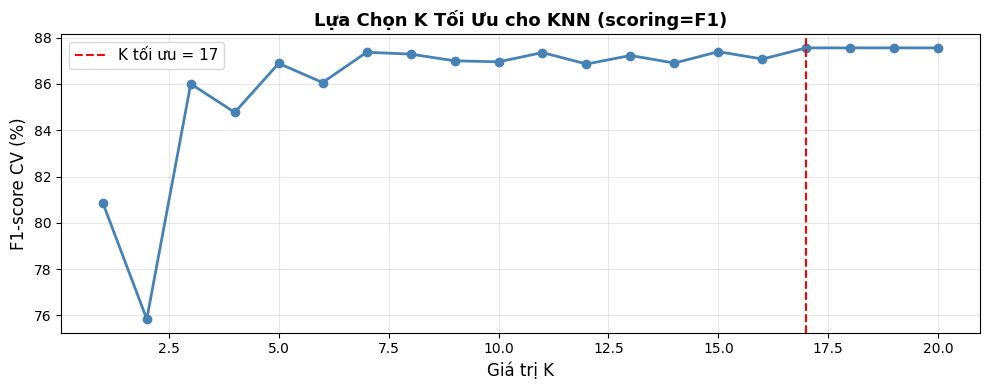

In [6]:
k_range     = range(1, 21)
knn_f1_cv   = []

for k in k_range:
    pipe = Pipeline([
        ('scaler', StandardScaler()),   # fit trên train fold
        ('knn',   KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=5, scoring='f1'
    )
    knn_f1_cv.append(scores.mean())

best_k = list(k_range)[np.argmax(knn_f1_cv)]
print(f'K tối ưu : K = {best_k}')
print(f'F1 CV    : {max(knn_f1_cv)*100:.2f}%')

plt.figure(figsize=(10, 4))
plt.plot(k_range, [s*100 for s in knn_f1_cv],
         marker='o', color='steelblue', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--',
            label=f'K tối ưu = {best_k}')
plt.xlabel('Giá trị K', fontsize=12)
plt.ylabel('F1-score CV (%)', fontsize=12)
plt.title('Lựa Chọn K Tối Ưu cho KNN (scoring=F1)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bieu_do_chon_k_knn.png', dpi=150)
plt.show()

=== KẾT QUẢ KNN (K=17) ===
Accuracy : 83.48%
F1-score : 89.27%  ← chỉ số chính

                precision    recall  f1-score   support

   Từ chối (0)       0.89      0.50      0.64        34
Được duyệt (1)       0.82      0.98      0.89        81

      accuracy                           0.83       115
     macro avg       0.86      0.74      0.77       115
  weighted avg       0.84      0.83      0.82       115



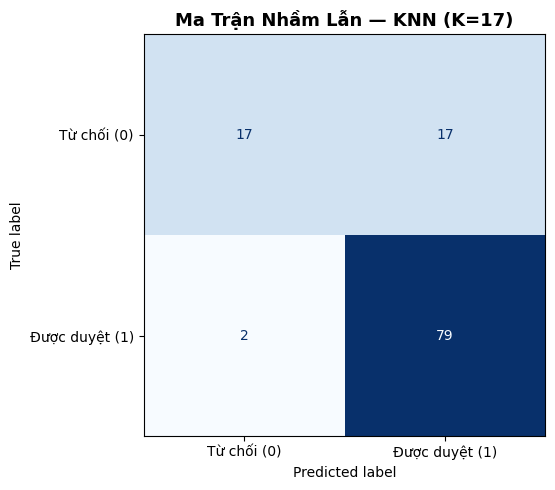

In [7]:
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',   KNeighborsClassifier(n_neighbors=best_k))
])
pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn  = f1_score(y_test, y_pred_knn)

print(f'=== KẾT QUẢ KNN (K={best_k}) ===')
print(f'Accuracy : {acc_knn*100:.2f}%')
print(f'F1-score : {f1_knn*100:.2f}%  ← chỉ số chính')
print()
print(classification_report(
    y_test, y_pred_knn,
    target_names=['Từ chối (0)', 'Được duyệt (1)']
))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_knn),
    display_labels=['Từ chối (0)', 'Được duyệt (1)']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Ma Trận Nhầm Lẫn — KNN (K={best_k})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_knn.png', dpi=150)
plt.show()

Depth tối ưu : 1
F1 CV        : 87.68%


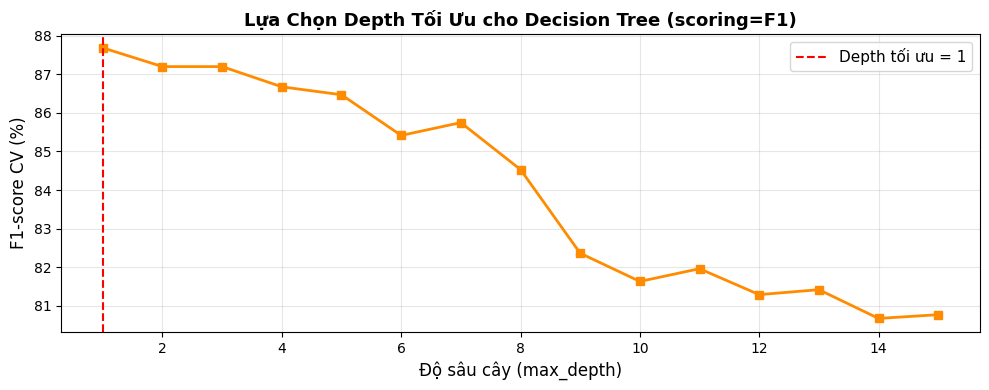

In [8]:
depth_range = range(1, 16)
dt_f1_cv    = []

for depth in depth_range:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('dt',    DecisionTreeClassifier(max_depth=depth, random_state=42))
    ])
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=5, scoring='f1'
    )
    dt_f1_cv.append(scores.mean())

best_depth = list(depth_range)[np.argmax(dt_f1_cv)]
print(f'Depth tối ưu : {best_depth}')
print(f'F1 CV        : {max(dt_f1_cv)*100:.2f}%')

plt.figure(figsize=(10, 4))
plt.plot(depth_range, [s*100 for s in dt_f1_cv],
         marker='s', color='darkorange', linewidth=2)
plt.axvline(x=best_depth, color='red', linestyle='--',
            label=f'Depth tối ưu = {best_depth}')
plt.xlabel('Độ sâu cây (max_depth)', fontsize=12)
plt.ylabel('F1-score CV (%)', fontsize=12)
plt.title('Lựa Chọn Depth Tối Ưu cho Decision Tree (scoring=F1)',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bieu_do_chon_depth_dt.png', dpi=150)
plt.show()

=== KẾT QUẢ DECISION TREE (depth=1) ===
Accuracy : 83.48%
F1-score : 89.27%  ← chỉ số chính

                precision    recall  f1-score   support

   Từ chối (0)       0.89      0.50      0.64        34
Được duyệt (1)       0.82      0.98      0.89        81

      accuracy                           0.83       115
     macro avg       0.86      0.74      0.77       115
  weighted avg       0.84      0.83      0.82       115



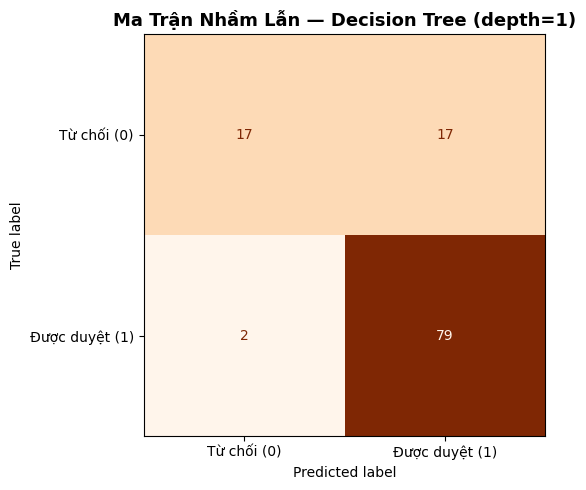

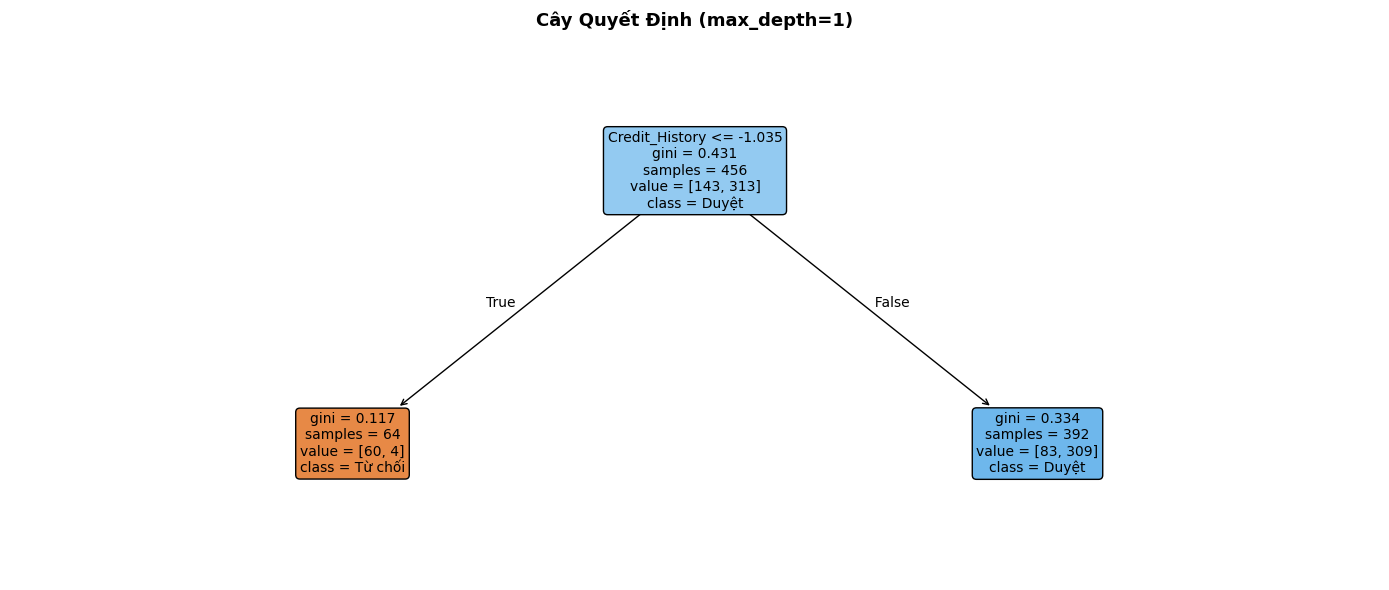

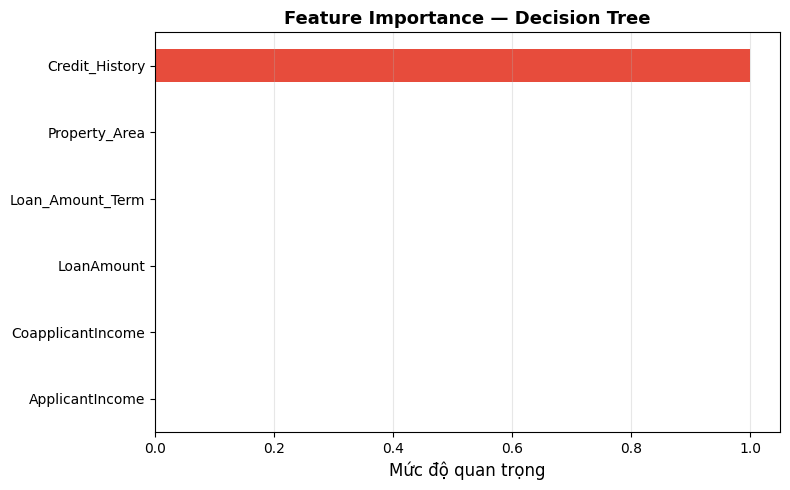

In [9]:
pipe_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('dt',    DecisionTreeClassifier(max_depth=best_depth, random_state=42))
])
pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt)

print(f'=== KẾT QUẢ DECISION TREE (depth={best_depth}) ===')
print(f'Accuracy : {acc_dt*100:.2f}%')
print(f'F1-score : {f1_dt*100:.2f}%  ← chỉ số chính')
print()
print(classification_report(
    y_test, y_pred_dt,
    target_names=['Từ chối (0)', 'Được duyệt (1)']
))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_dt),
    display_labels=['Từ chối (0)', 'Được duyệt (1)']
).plot(ax=ax, colorbar=False, cmap='Oranges')
ax.set_title(f'Ma Trận Nhầm Lẫn — Decision Tree (depth={best_depth})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_dt.png', dpi=150)
plt.show()

# Cây quyết định
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(
    pipe_dt.named_steps['dt'],
    feature_names=X.columns.tolist(),
    class_names=['Từ chối', 'Duyệt'],
    filled=True, rounded=True, fontsize=10, ax=ax
)
ax.set_title(f'Cây Quyết Định (max_depth={best_depth})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cay_quyet_dinh.png', dpi=150)
plt.show()

# Feature Importance
importances = pd.Series(
    pipe_dt.named_steps['dt'].feature_importances_,
    index=X.columns
).sort_values()
plt.figure(figsize=(8, 5))
colors = ['#e74c3c' if v == importances.max() else '#3498db'
          for v in importances]
importances.plot(kind='barh', color=colors)
plt.xlabel('Mức độ quan trọng', fontsize=12)
plt.title('Feature Importance — Decision Tree',
          fontsize=13, fontweight='bold')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_dt.png', dpi=150)
plt.show()

✅ File Phần 3: K=3 | Acc=75.65% | F1=83.33%

   SO SÁNH 1: KIỂM CHỨNG LOGIC KNN TỰ CODE vs SKLEARN
Mô hình                               Accuracy   F1-score
--------------------------------------------------------------------
KNN Tự Code (Phần 3, K=3)               75.65%     83.33%
KNN Sklearn (K=3) ← cùng K              75.65%     83.33%

Chênh lệch Accuracy : 0.00%
Chênh lệch F1-score : 0.00%
✅ Kết quả khớp → Thuật toán tự code CHÍNH XÁC!


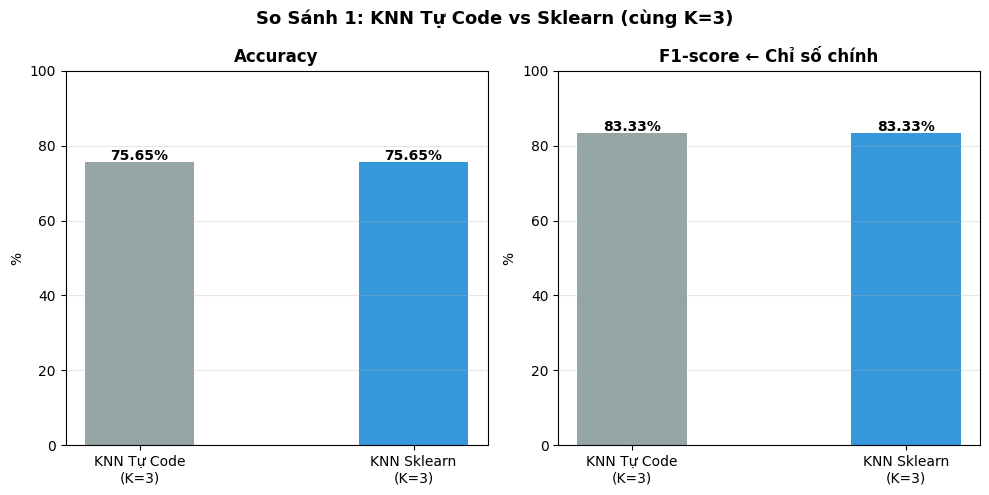

In [10]:
# ── Đọc kết quả Phần 3 từ file ────────────────────────────────────
try:
    phan3      = pd.read_csv('ket_qua_phan3.csv')
    acc_p3     = float(phan3['accuracy'].iloc[0])
    f1_p3      = float(phan3['f1_score'].iloc[0])
    k_p3       = int(phan3['k'].iloc[0])
    print(f'✅ File Phần 3: K={k_p3} | Acc={acc_p3*100:.2f}% | F1={f1_p3*100:.2f}%')
except:
    print('⚠️  Chưa có ket_qua_phan3.csv → dùng giá trị tạm')
    acc_p3, f1_p3, k_p3 = 0.7826, 0.8485, 3

# ── KNN sklearn cùng K với Phần 3 ─────────────────────────────────
pipe_k3 = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',   KNeighborsClassifier(n_neighbors=k_p3))
])
pipe_k3.fit(X_train, y_train)
y_pred_k3 = pipe_k3.predict(X_test)
acc_k3    = accuracy_score(y_test, y_pred_k3)
f1_k3     = f1_score(y_test, y_pred_k3)

# ── Bảng So Sánh 1 ────────────────────────────────────────────────
print()
print('=' * 68)
print('   SO SÁNH 1: KIỂM CHỨNG LOGIC KNN TỰ CODE vs SKLEARN')
print('=' * 68)
print(f'{"Mô hình":<35} {"Accuracy":>10} {"F1-score":>10}')
print('-' * 68)
print(f'{"KNN Tự Code (Phần 3, K="+str(k_p3)+")":<35} {acc_p3*100:>9.2f}% {f1_p3*100:>9.2f}%')
print(f'{"KNN Sklearn (K="+str(k_p3)+") ← cùng K":<35} {acc_k3*100:>9.2f}% {f1_k3*100:>9.2f}%')
print('=' * 68)

diff_acc = abs(acc_p3 - acc_k3) * 100
diff_f1  = abs(f1_p3  - f1_k3)  * 100
print(f'\nChênh lệch Accuracy : {diff_acc:.2f}%')
print(f'Chênh lệch F1-score : {diff_f1:.2f}%')
if diff_f1 <= 3:
    print('✅ Kết quả khớp → Thuật toán tự code CHÍNH XÁC!')
else:
    print('⚠️  Chênh lệch lớn → Kiểm tra lại logic hoặc cách chia data Phần 3')

# Biểu đồ So sánh 1
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

labels = [f'KNN Tự Code\n(K={k_p3})', f'KNN Sklearn\n(K={k_p3})']
colors = ['#95a5a6', '#3498db']

ax1.bar(labels, [acc_p3*100, acc_k3*100], color=colors, width=0.4)
for i, v in enumerate([acc_p3*100, acc_k3*100]):
    ax1.text(i, v+0.5, f'{v:.2f}%', ha='center', fontweight='bold')
ax1.set_ylim(0, 100)
ax1.set_title('Accuracy', fontsize=12, fontweight='bold')
ax1.set_ylabel('%')
ax1.grid(True, axis='y', alpha=0.3)

ax2.bar(labels, [f1_p3*100, f1_k3*100], color=colors, width=0.4)
for i, v in enumerate([f1_p3*100, f1_k3*100]):
    ax2.text(i, v+0.5, f'{v:.2f}%', ha='center', fontweight='bold')
ax2.set_ylim(0, 100)
ax2.set_title('F1-score ← Chỉ số chính', fontsize=12, fontweight='bold')
ax2.set_ylabel('%')
ax2.grid(True, axis='y', alpha=0.3)

plt.suptitle(f'So Sánh 1: KNN Tự Code vs Sklearn (cùng K={k_p3})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('so_sanh_1_kiem_chung.png', dpi=150)
plt.show()

   SO SÁNH 2: KNN SKLEARN vs DECISION TREE (tối ưu F1)
Mô hình                               Accuracy   F1-score
--------------------------------------------------------------------
KNN Sklearn (K=17)                      83.48%     89.27%
Decision Tree (depth=1)                 83.48%     89.27%

🤝 Hai mô hình cho kết quả tương đương
   F1-score cùng đạt: 89.27%


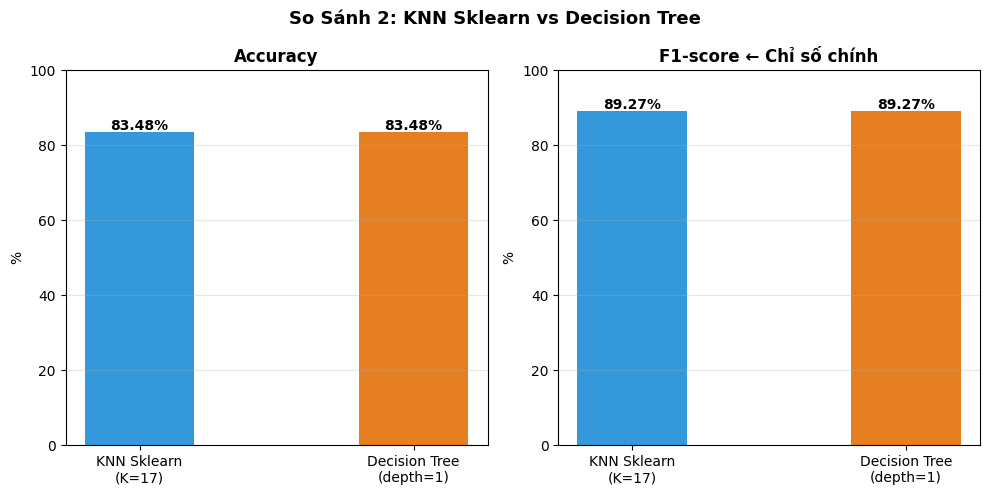

In [19]:
print('=' * 68)
print('   SO SÁNH 2: KNN SKLEARN vs DECISION TREE (tối ưu F1)')
print('=' * 68)
print(f'{"Mô hình":<35} {"Accuracy":>10} {"F1-score":>10}')
print('-' * 68)
print(f'{"KNN Sklearn (K="+str(best_k)+")":<35} {acc_knn*100:>9.2f}% {f1_knn*100:>9.2f}%')
print(f'{"Decision Tree (depth="+str(best_depth)+")":<35} {acc_dt*100:>9.2f}% {f1_dt*100:>9.2f}%')
print('=' * 68)

# So sánh F1-score

if f1_dt > f1_knn:

    winner = f'Decision Tree (depth={best_depth})'
    winner_f1 = f1_dt

    print(f'\n🏆 Mô hình tốt hơn: {winner}')
    print(f'   F1-score: {winner_f1*100:.2f}%')

elif f1_knn > f1_dt:

    winner = f'KNN Sklearn (K={best_k})'
    winner_f1 = f1_knn

    print(f'\n🏆 Mô hình tốt hơn: {winner}')
    print(f'   F1-score: {winner_f1*100:.2f}%')

else:

    print('\n🤝 Hai mô hình cho kết quả tương đương')
    print(f'   F1-score cùng đạt: {f1_knn*100:.2f}%')

# Biểu đồ So sánh 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

labels = [f'KNN Sklearn\n(K={best_k})', f'Decision Tree\n(depth={best_depth})']
colors = ['#3498db', '#e67e22']

ax1.bar(labels, [acc_knn*100, acc_dt*100], color=colors, width=0.4)
for i, v in enumerate([acc_knn*100, acc_dt*100]):
    ax1.text(i, v+0.5, f'{v:.2f}%', ha='center', fontweight='bold')
ax1.set_ylim(0, 100)
ax1.set_title('Accuracy', fontsize=12, fontweight='bold')
ax1.set_ylabel('%')
ax1.grid(True, axis='y', alpha=0.3)

ax2.bar(labels, [f1_knn*100, f1_dt*100], color=colors, width=0.4)
for i, v in enumerate([f1_knn*100, f1_dt*100]):
    ax2.text(i, v+0.5, f'{v:.2f}%', ha='center', fontweight='bold')
ax2.set_ylim(0, 100)
ax2.set_title('F1-score ← Chỉ số chính', fontsize=12, fontweight='bold')
ax2.set_ylabel('%')
ax2.grid(True, axis='y', alpha=0.3)

plt.suptitle('So Sánh 2: KNN Sklearn vs Decision Tree',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('so_sanh_2_thuat_toan.png', dpi=150)
plt.show()

In [20]:
import sqlite3

# =========================================================
# KẾT NỐI DATABASE
# =========================================================

conn = sqlite3.connect('QuanLyTinDung.db')
cursor = conn.cursor()

# =========================================================
# XÓA BẢNG CŨ (TRÁNH LỖI KHÁC CẤU TRÚC)
# =========================================================

cursor.execute("DROP TABLE IF EXISTS du_doan")
cursor.execute("DROP TABLE IF EXISTS xac_suat")

# =========================================================
# TẠO BẢNG du_doan
# =========================================================

cursor.execute("""
CREATE TABLE du_doan (
    ID                  INTEGER PRIMARY KEY AUTOINCREMENT,
    ApplicantIncome     REAL,
    CoapplicantIncome   REAL,
    LoanAmount          REAL,
    Loan_Amount_Term    REAL,
    Credit_History      REAL,
    Property_Area       INTEGER,
    KetQuaThucTe        INTEGER,
    DuDoan_KNN          INTEGER,
    DuDoan_DT           INTEGER,
    KNN_Dung            INTEGER,
    DT_Dung             INTEGER
)
""")

# =========================================================
# TẠO BẢNG xac_suat
# =========================================================

cursor.execute("""
CREATE TABLE xac_suat (
    ID          INTEGER PRIMARY KEY AUTOINCREMENT,
    TenMoHinh   TEXT,
    ThamSo      TEXT,
    Loai        TEXT,
    Accuracy    REAL,
    F1_Score    REAL
)
""")

conn.commit()

print('✅ Đã tạo 2 bảng: du_doan + xac_suat')

# =========================================================
# ĐẨY TỪNG HỒ SƠ TEST
# =========================================================

df_result = X_test.copy().reset_index(drop=True)

df_result['KetQuaThucTe'] = y_test.values
df_result['DuDoan_KNN']   = y_pred_knn
df_result['DuDoan_DT']    = y_pred_dt

df_result['KNN_Dung'] = (
    y_pred_knn == y_test.values
).astype(int)

df_result['DT_Dung'] = (
    y_pred_dt == y_test.values
).astype(int)

for _, row in df_result.iterrows():

    cursor.execute("""
        INSERT INTO du_doan VALUES
        (NULL,?,?,?,?,?,?,?,?,?,?,?)
    """, (
        float(row['ApplicantIncome']),
        float(row['CoapplicantIncome']),
        float(row['LoanAmount']),
        float(row['Loan_Amount_Term']),
        float(row['Credit_History']),
        int(row['Property_Area']),
        int(row['KetQuaThucTe']),
        int(row['DuDoan_KNN']),
        int(row['DuDoan_DT']),
        int(row['KNN_Dung']),
        int(row['DT_Dung'])
    ))

# =========================================================
# ĐẨY KẾT QUẢ MÔ HÌNH
# =========================================================

models = [
    ('KNN Tự Code',   f'K={k_p3}',           'Tự cài đặt', acc_p3,  f1_p3),
    ('KNN Sklearn',   f'K={k_p3}',           'Thư viện',   acc_k3,  f1_k3),
    ('KNN Sklearn',   f'K={best_k}',         'Thư viện',   acc_knn, f1_knn),
    ('Decision Tree', f'depth={best_depth}', 'Thư viện',   acc_dt,  f1_dt),
]

for row in models:

    cursor.execute("""
        INSERT INTO xac_suat
        VALUES (NULL,?,?,?,?,?)
    """, row)

conn.commit()

print(f'✅ Đã lưu {len(df_result)} hồ sơ vào du_doan')
print(f'✅ Đã lưu {len(models)} mô hình vào xac_suat')

# =========================================================
# TRUY VẤN SQL
# =========================================================

print('\n--- Accuracy từng mô hình ---')

print(pd.read_sql("""
    SELECT
        TenMoHinh,
        ThamSo,
        Loai,
        ROUND(Accuracy*100,2) as Accuracy,
        ROUND(F1_Score*100,2) as F1_Score
    FROM xac_suat
""", conn).to_string(index=False))

# =========================================================
# HỒ SƠ CẢ 2 MÔ HÌNH ĐỀU SAI
# =========================================================

print('\n--- Hồ sơ cả 2 mô hình đều sai ---')

df_ca2_sai = pd.read_sql("""
    SELECT *
    FROM du_doan
    WHERE KNN_Dung=0 AND DT_Dung=0
""", conn)

print(f'Số hồ sơ cả 2 đều sai: {len(df_ca2_sai)}')

# =========================================================
# ACCURACY THEO Credit_History
# =========================================================

print('\n--- Accuracy theo Credit_History ---')

print(pd.read_sql("""
    SELECT
        Credit_History,
        COUNT(*) as TongHoSo,

        ROUND(
            AVG(CAST(DT_Dung AS FLOAT))*100,
            1
        ) as DT_Accuracy,

        ROUND(
            AVG(CAST(KNN_Dung AS FLOAT))*100,
            1
        ) as KNN_Accuracy

    FROM du_doan

    GROUP BY Credit_History
""", conn).to_string(index=False))

# =========================================================
# ĐÓNG DATABASE
# =========================================================

conn.close()

# =========================================================
# DOWNLOAD FILE SQLITE
# =========================================================


# from google.colab import files
# files.download('QuanLyTinDung.db')

print('\n✅ Đã download QuanLyTinDung.db!')

✅ Đã tạo 2 bảng: du_doan + xac_suat
✅ Đã lưu 115 hồ sơ vào du_doan
✅ Đã lưu 4 mô hình vào xac_suat

--- Accuracy từng mô hình ---
    TenMoHinh  ThamSo       Loai  Accuracy  F1_Score
  KNN Tự Code     K=3 Tự cài đặt     75.65     83.33
  KNN Sklearn     K=3   Thư viện     75.65     83.33
  KNN Sklearn    K=17   Thư viện     83.48     89.27
Decision Tree depth=1   Thư viện     83.48     89.27

--- Hồ sơ cả 2 mô hình đều sai ---
Số hồ sơ cả 2 đều sai: 19

--- Accuracy theo Credit_History ---
 Credit_History  TongHoSo  DT_Accuracy  KNN_Accuracy
            0.0        19         89.5          89.5
            1.0        96         82.3          82.3

✅ Đã download QuanLyTinDung.db!
